# Part B: Deep Learning Architectures

## B2: Convolutional Neural Network (CNN)
### CIFAR-10 Image Classification

This project implements a Convolutional Neural Network (CNN) to classify images using the CIFAR-10 dataset.

The dataset contains 60,000 color images belonging to 10 different classes.

The objective is to train a CNN model to recognize and classify these images into their correct categories.


## Step 1: Importing Required Libraries

The required Python libraries are imported for loading the CIFAR-10 dataset, data processing, visualization, and building the CNN model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.21.0


## Step 2: Loading the CIFAR-10 Dataset

The CIFAR-10 dataset is loaded using TensorFlow Keras.

The dataset is divided into training and testing sets. The shape and number of images are checked to understand the dataset.

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Dataset loaded successfully!")

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2318s 14us/step


d:\install\python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = RestrictedUnpickler(f, encoding="bytes").load()


Dataset loaded successfully!
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)
Number of training samples: 50000
Number of testing samples: 10000


## Step 4: Visualizing the Dataset

A sample of images from the CIFAR-10 dataset is displayed to understand the different image classes used for classification.


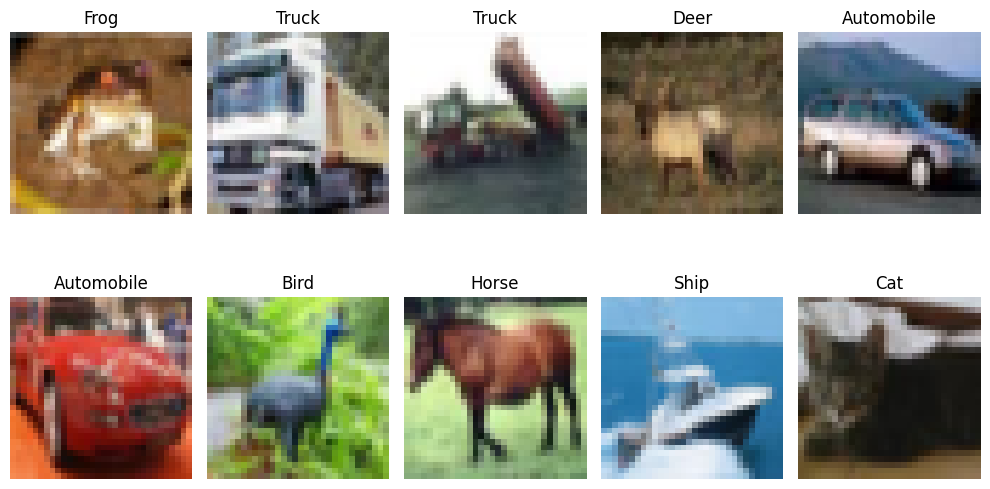

In [3]:
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 5: Data Preprocessing

The image pixel values are normalized to a range of 0 to 1 by dividing them by 255.

This helps the CNN model process the images during training. The training and testing datasets are prepared for model building.

In [4]:
# Normalize image pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Images normalized successfully!")

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Images normalized successfully!
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Step 6: Building the CNN Model

A Convolutional Neural Network (CNN) is built using convolutional, max-pooling, and dense layers.

The model uses ReLU activation in the hidden layers and Softmax activation in the output layer to classify images into 10 CIFAR-10 categories.




In [5]:
cnn_model = Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Training the CNN Model

The CNN model is trained using the CIFAR-10 training dataset.

The model is trained for 10 epochs with a batch size of 64. A validation split is used to monitor the model's performance during training.





In [6]:
history = cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

print("CNN training completed successfully!")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.3842 - loss: 1.6810 - val_accuracy: 0.5139 - val_loss: 1.3671
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5061 - loss: 1.3688 - val_accuracy: 0.5644 - val_loss: 1.2315
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5572 - loss: 1.2424 - val_accuracy: 0.5923 - val_loss: 1.1554
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5867 - loss: 1.1580 - val_accuracy: 0.6252 - val_loss: 1.0699
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6112 - loss: 1.0980 - val_accuracy: 0.6376 - val_loss: 1.0227
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6267 - loss: 1.0523 - val_accuracy: 0.6585 - val_loss: 0.9753
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.6437 - loss: 1.0065 - val_accuracy: 0.6574 - val_loss: 0.9636
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.6578 - loss: 0.9662 - 

## Step 8: Training and Validation Curves

The training and validation accuracy and loss are visualized to analyze the learning performance of the CNN model over 10 epochs.

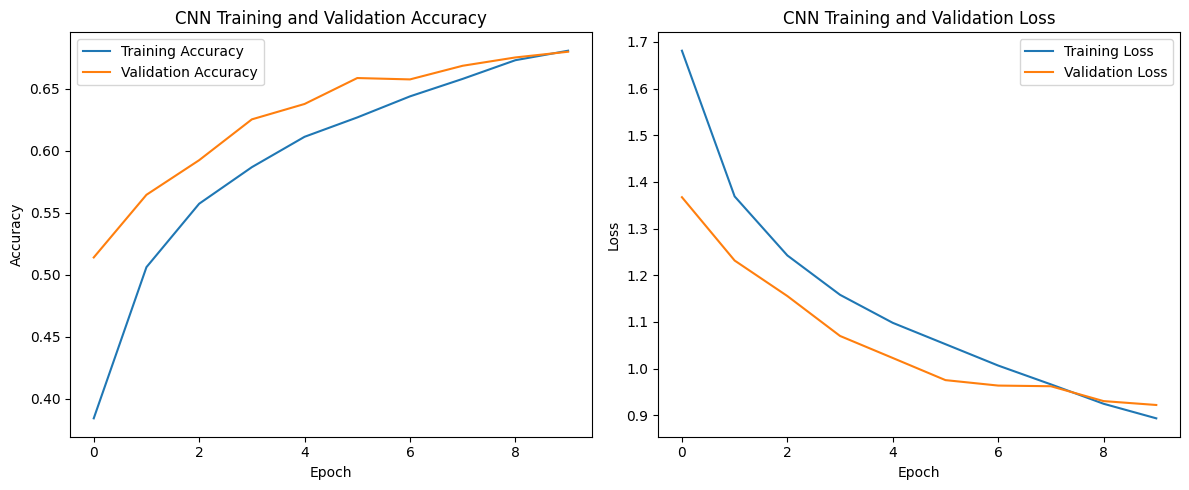

In [7]:
plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 9: Model Evaluation

The trained CNN model is evaluated on the test dataset. Accuracy, precision, recall, and F1-score are used to measure its classification performance.


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predict test images
y_prob = cnn_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.ravel()

# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("CNN Model Evaluation")
print("--------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
CNN Model Evaluation
--------------------
Accuracy: 0.6708
Precision: 0.6757
Recall: 0.6708
F1-Score: 0.6699

Classification Report:
              precision    recall  f1-score   support

    Airplane       0.77      0.66      0.71      1000
  Automobile       0.79      0.79      0.79      1000
        Bird       0.52      0.59      0.55      1000
         Cat       0.48      0.49      0.49      1000
        Deer       0.67      0.54      0.60      1000
         Dog       0.61      0.54      0.58      1000
        Frog       0.64      0.84      0.72      1000
       Horse       0.76      0.69      0.72      1000
        Ship       0.79      0.77      0.78      1000
       Truck       0.71      0.80      0.75      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.67     10000
weighted avg       0.68      0.67      0.67     10000



## Step 10: Confusion Matrix

A confusion matrix is used to visualize the classification performance of the CNN model. It shows the correct and incorrect predictions for each image class.



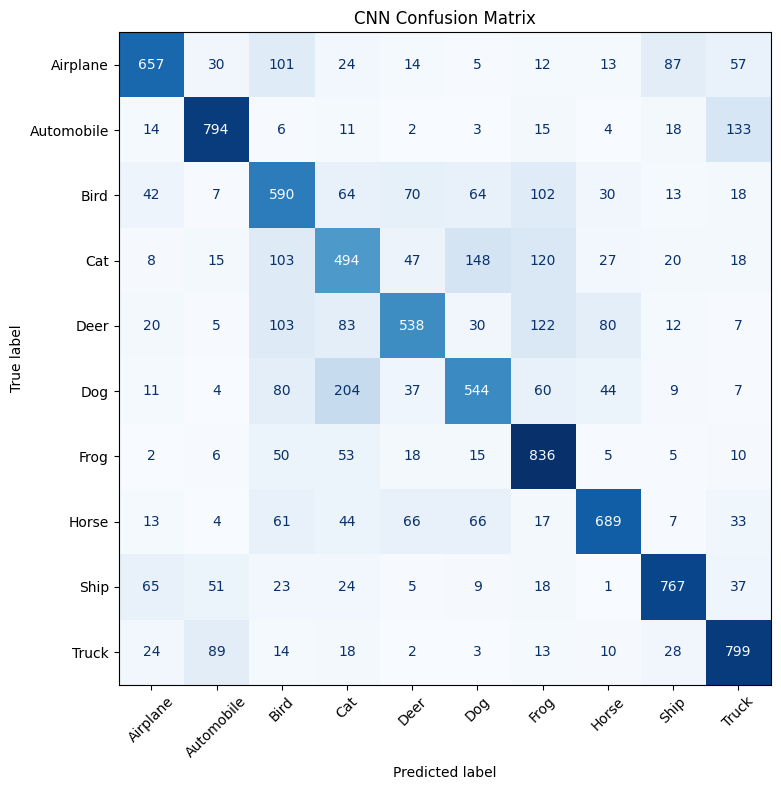

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)

plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

## Step 11: Save CNN Results

The CNN evaluation metrics, training curves, and confusion matrix are saved for documentation and future reference.



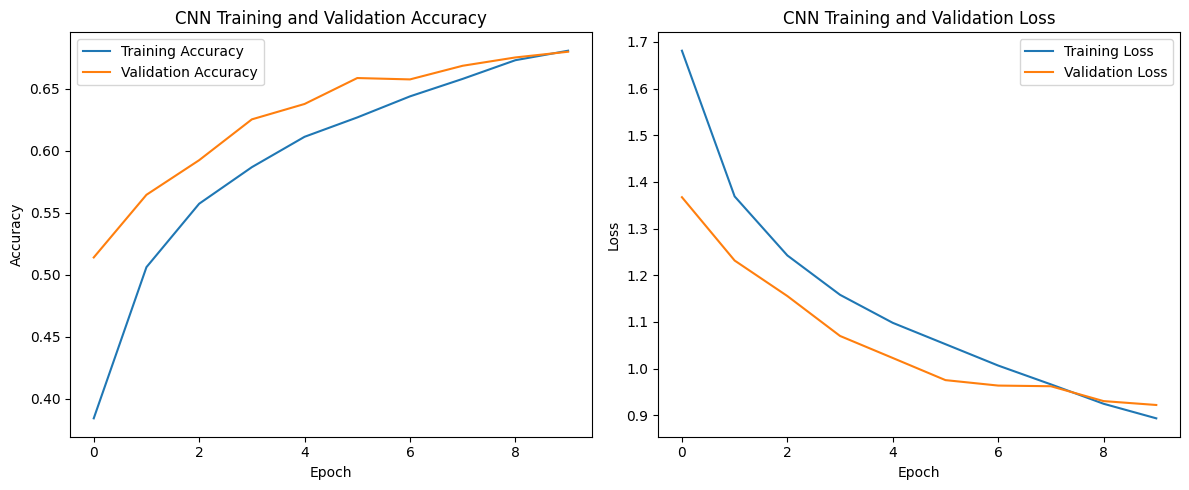

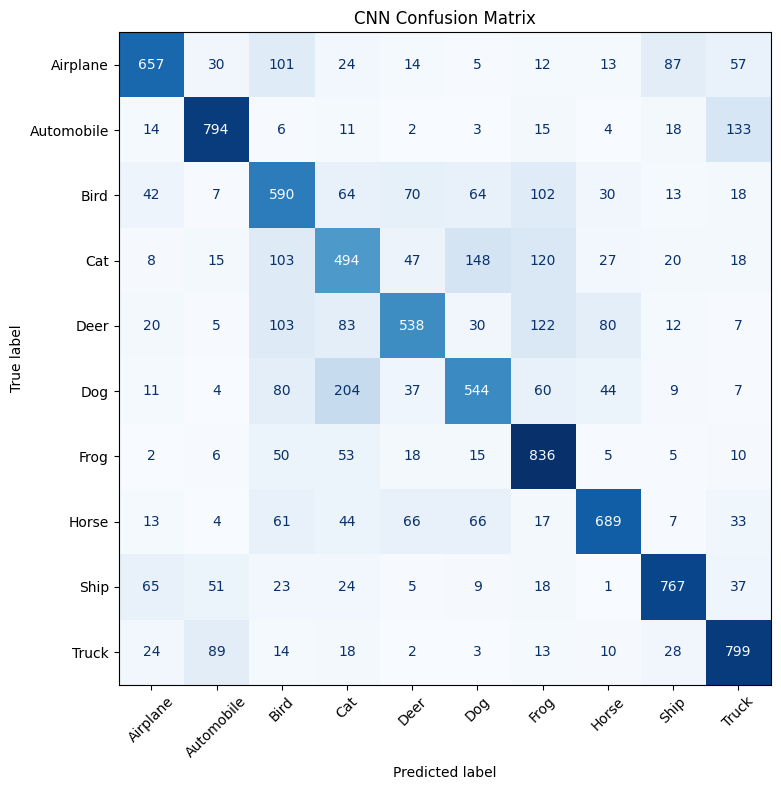

CNN results saved successfully!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Save evaluation metrics
cnn_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

cnn_results.to_csv("CNN_Evaluation_Metrics.csv", index=False)

# Save training and validation curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("CNN_Training_Curves.png", dpi=300, bbox_inches="tight")
plt.show()

# Save confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.savefig("CNN_Confusion_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Save confusion matrix data
pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
).to_csv("CNN_Confusion_Matrix.csv")

print("CNN results saved successfully!")